# 20260630 pairwise interaction — relative abundance & competitive hierarchy

Same method as the [20260721 relative_abundance analysis](../../../20260721/analysis/relative_abundance/relative_abundance_20260721.ipynb),
run here via the shared, experiment-parameterized pipeline in `../../../shared_pipelines/`.

**Reference**: `analysis/consensus2/strain_consensus_20260630.fasta` (84 strains — the more
recent/refined of two independent per-strain consensus builds for this experiment).
**Guide**: `setup/strain_layout_20260630.csv`. **Cohort**: the same >5-read pair wells
already identified in `analysis/mapping_validation` (2,778 wells, of which 1,968 have a
resolvable reference for both strains).

Same four questions as 20260721:

1. **Interaction score per well** — reads matching neither expected strain are quantified,
   not discarded; (near-)identical strain pairs fall out to 50/50 with maximal uncertainty
   automatically, from the same classifier used for every other pair.
2. **Replicate stability** — for strain pairs plated more than once, does the score reproduce?
3. **Per-strain competitiveness score** — averaged across every distinct opponent tested.
4. **Hierarchy vs. tangled network** — Bradley-Terry model + Directional Consistency Index +
   intransitive-triad fraction.


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR.parent))  # analysis/ (config.py lives here, shared by both pipelines)

import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

from config import CFG  # also puts shared_pipelines/ on sys.path as a side effect

OUT_DIR = CFG.relative_abundance_out_dir
FIG_DIR = CFG.relative_abundance_fig_dir

def show(png_name, width=880):
    display(Image(filename=str(FIG_DIR / png_name), width=width))

print(f"reference -> {CFG.ra_reference_fasta}")
print(f"cohort    -> {CFG.mapping_validation_out_dir / '01_samples_gt5reads.csv'}")
print(f"outputs   -> {OUT_DIR}")


reference -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus2/strain_consensus_20260630.fasta
cohort    -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/01_samples_gt5reads.csv
outputs   -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs


## Step 1 — reference-pair distances

For every unique strain pair actually tested, how far apart are the two strains' own
reference sequences? **This strain library has a notably larger near-identical cluster than
20260721's**: 12 pairs with completely identical (0bp) references (vs. 1 for 20260721), and
103 pairs within 10bp (vs. 31) — expect a higher uncertainty rate throughout this analysis as
a direct consequence.


In [2]:
from relative_abundance import reference_distances

ref_dist = reference_distances(CFG)
display(ref_dist.sort_values("bp_dist").head(10))


2365 unique tested strain pairs (688 missing a reference for one strain)
reference-pair bp distance among resolvable pairs: min=0, median=202, max=338
pairs with identical (0 bp) references: 12
pairs with <10 bp difference: 103
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r01_reference_pair_distances.csv


,strain_a,strain_b,bp_dist,norm_dist,len_a,len_b,missing_reference
504,C20,E22,0.0,0.0,1423.0,1423.0,False
1768,G17,J13,0.0,0.0,1419.0,1419.0,False
457,C14,E4,0.0,0.0,1421.0,1421.0,False
899,E16,E21,0.0,0.0,1431.0,1431.0,False
709,E10,G3,0.0,0.0,1422.0,1422.0,False
710,E10,G5,0.0,0.0,1422.0,1422.0,False
1747,G15,O9,0.0,0.0,1422.0,1422.0,False
2092,H15,H17,0.0,0.0,1422.0,1422.0,False
1933,G3,G5,0.0,0.0,1422.0,1422.0,False
1605,G1,H15,0.0,0.0,1422.0,1422.0,False


## Step 2 — per-well interaction scoring

In [3]:
from relative_abundance import compute_interaction_scores

wells, reads = compute_interaction_scores(CFG)


data-driven off-target threshold (learned from 1968 wells' read distances): 0.128
2778 pair wells (810 skipped, missing a reference for one strain)
82070 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r02_read_assignments.csv.gz
read_class breakdown:
read_class
ambiguous     28543
strain2       25613
strain1       23930
off_target     3984

median off_target_frac: 0.000
median uncertainty_score: 0.039
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r02_well_interaction_scores.csv


In [4]:
display(Markdown("**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:"))
example_cols = ["sample_id", "strain1", "strain2", "n_reads", "ref_pair_bp_dist",
                "uncertainty_score", "relative_abundance_strain1", "log2_ratio_strain1_over_strain2"]
indistinguishable = wells[(wells.ref_pair_bp_dist == 0)].head(3)
separated = wells.sort_values("ref_pair_bp_dist", ascending=False).head(1)
display(pd.concat([indistinguishable, separated])[example_cols])


**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:

,sample_id,strain1,strain2,n_reads,ref_pair_bp_dist,uncertainty_score,relative_abundance_strain1,log2_ratio_strain1_over_strain2
318,Plate03_C19,E22,C20,41,0.0,1.0,0.5,0.000000
606,Plate05_C14,G3,E10,34,0.0,1.0,0.5,0.000000
1037,Plate07_J10,G5,G3,40,0.0,1.0,0.5,0.000000
1303,Plate09_H4,A6,E6,40,338.0,0.0,0.4,-0.570316


In [5]:
from relative_abundance import make_all_figures

make_all_figures(CFG)


saved 8 figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/figures


**Read classification & per-well quality**, and the overall interaction-outcome distribution:

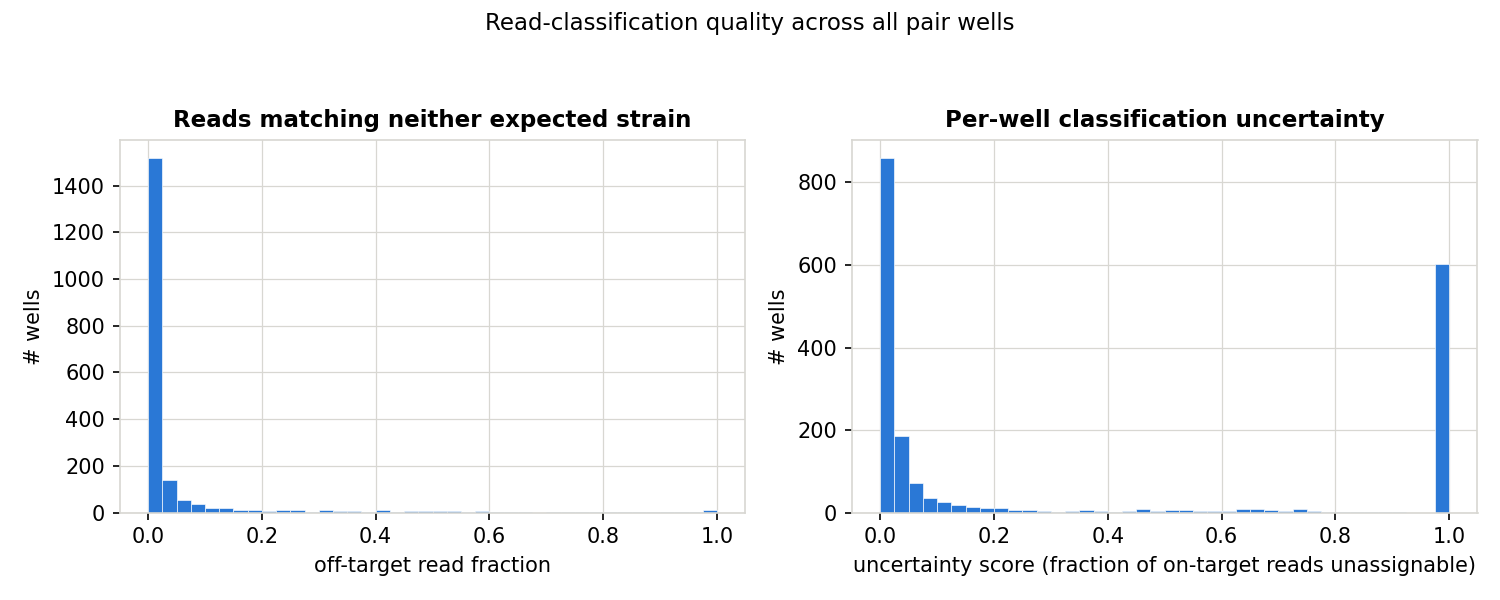

In [6]:
show("00_read_classification_quality.png")

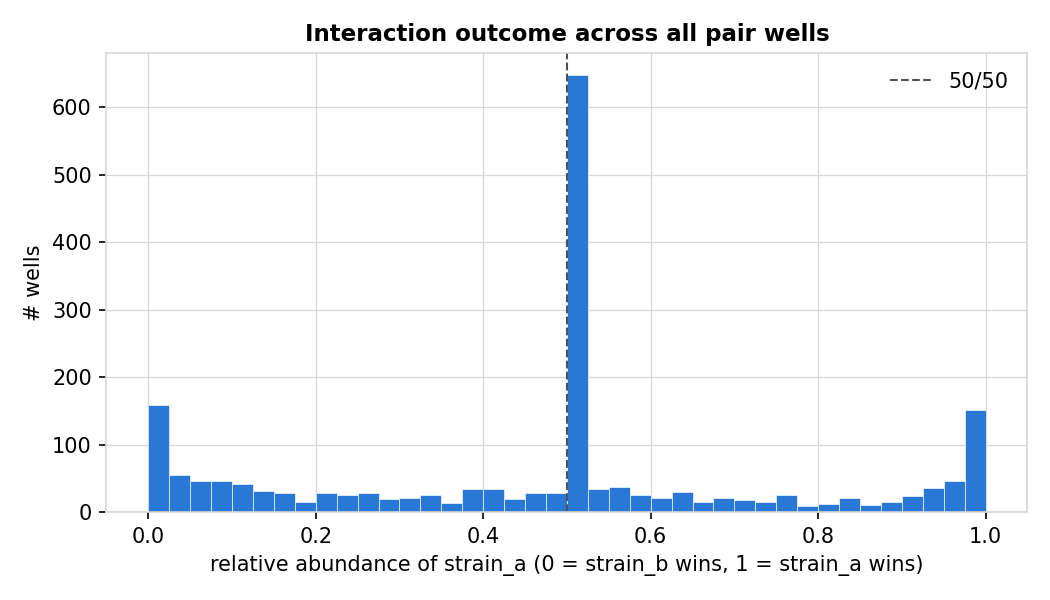

In [7]:
show("01_abundance_distribution.png")

## Step 3 — replicate stability

In [8]:
from relative_abundance import replicate_stability

pair_stats = replicate_stability(CFG)


1677 unique pairs total; 291 have >=2 replicate wells
  of which 169 are NOT high-uncertainty (reliable measurement)
  median std(relative_abundance_a) across replicated pairs: 0.011
  median std, excluding high-uncertainty pairs: 0.030
  flagged unstable (std > 0.15): 11
  flagged unstable AND not high-uncertainty (genuine biological instability): 11
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/relative_abundance/outputs/r03_pair_replicate_stats.csv


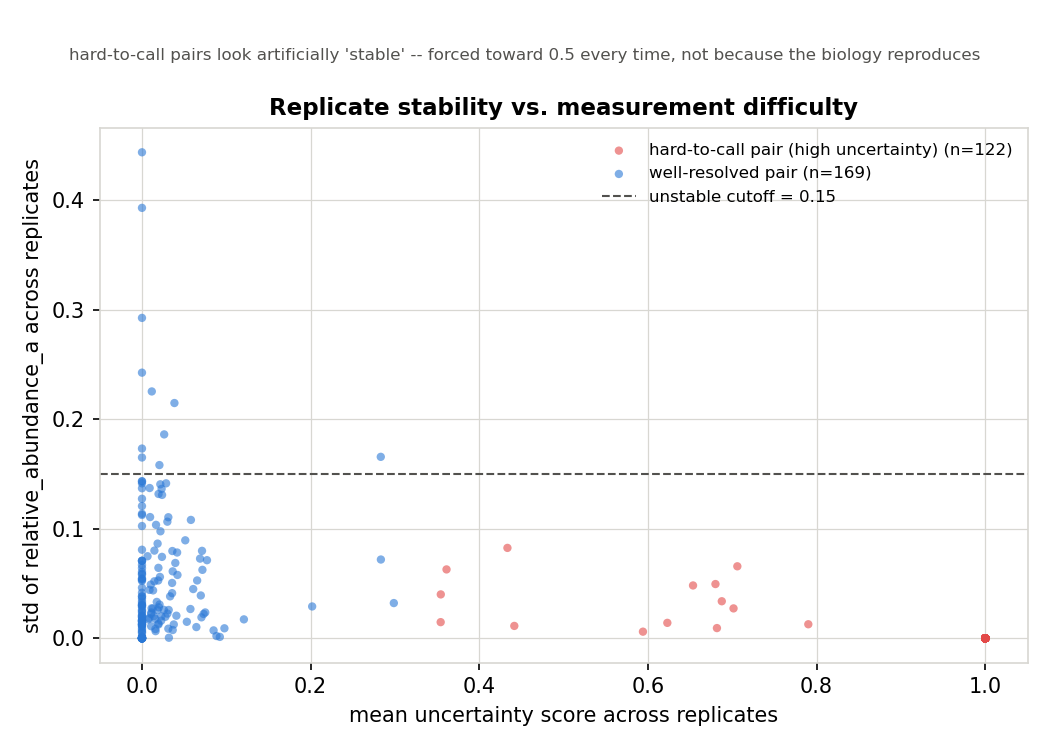

In [9]:
show("02_replicate_stability.png")

In [10]:
unstable = pair_stats[pair_stats.unstable_replicate & ~pair_stats.high_uncertainty_pair]
display(Markdown(f"**{len(unstable)} pairs show genuine (not measurement-driven) replicate instability**:"))
display(unstable.sort_values("std_relative_abundance_a", ascending=False)
        [["strain_a","strain_b","n_replicates","mean_relative_abundance_a","std_relative_abundance_a","mean_uncertainty_score"]]
        .head(10))


**11 pairs show genuine (not measurement-driven) replicate instability**:

,strain_a,strain_b,n_replicates,mean_relative_abundance_a,std_relative_abundance_a,mean_uncertainty_score
1241,G2,M19,2,0.413636,0.443549,0.000000
1208,G17,G9,2,0.722222,0.392837,0.000000
1429,G8,O7,2,0.635338,0.292413,0.000000
107,A12,G7,2,0.828571,0.242437,0.000000
164,A21,A6,2,0.759302,0.225288,0.011628
1656,O17,O9,2,0.309717,0.214709,0.038462
1405,G7,M19,2,0.368421,0.186081,0.026316
52,A11,F17,2,0.254025,0.173165,0.000000
830,E24,J1,2,0.336393,0.165597,0.283150
245,A6,M11,2,0.883333,0.164992,0.000000


## Step 4 — per-strain competitiveness score

In [11]:
from relative_abundance import competitiveness_scores

comp = competitiveness_scores(CFG)


76/100 strains scored
  NOT scored (no resolvable reference / no tested pairs survived filtering): ['A10', 'A15', 'A2', 'E14', 'E15', 'E5', 'E8', 'F21', 'G10', 'G11', 'G12', 'G13', 'G14', 'G18', 'G19', 'G23', 'H5', 'H7', 'I3', 'J11', 'J3', 'M9', 'P21', 'P23']

top 5 most competitive:
strain  competitiveness_score  win_fraction  n_opponents
   J13               2.941990      0.860465           43
    J5               2.306151      0.790698           43
   O17               2.230489      0.666667           42
   G17               2.182234      0.843137           51
   F15               1.867834      0.500000           42

bottom 5 least competitive:
strain  competitiveness_score  win_fraction  n_opponents
   P19              -2.334654      0.000000           38
   O11              -2.363729      0.000000           46
   E20              -2.478254      0.028571           35
   O21              -2.496761      0.230769           39
   M13              -3.025786      0.000000           38

s

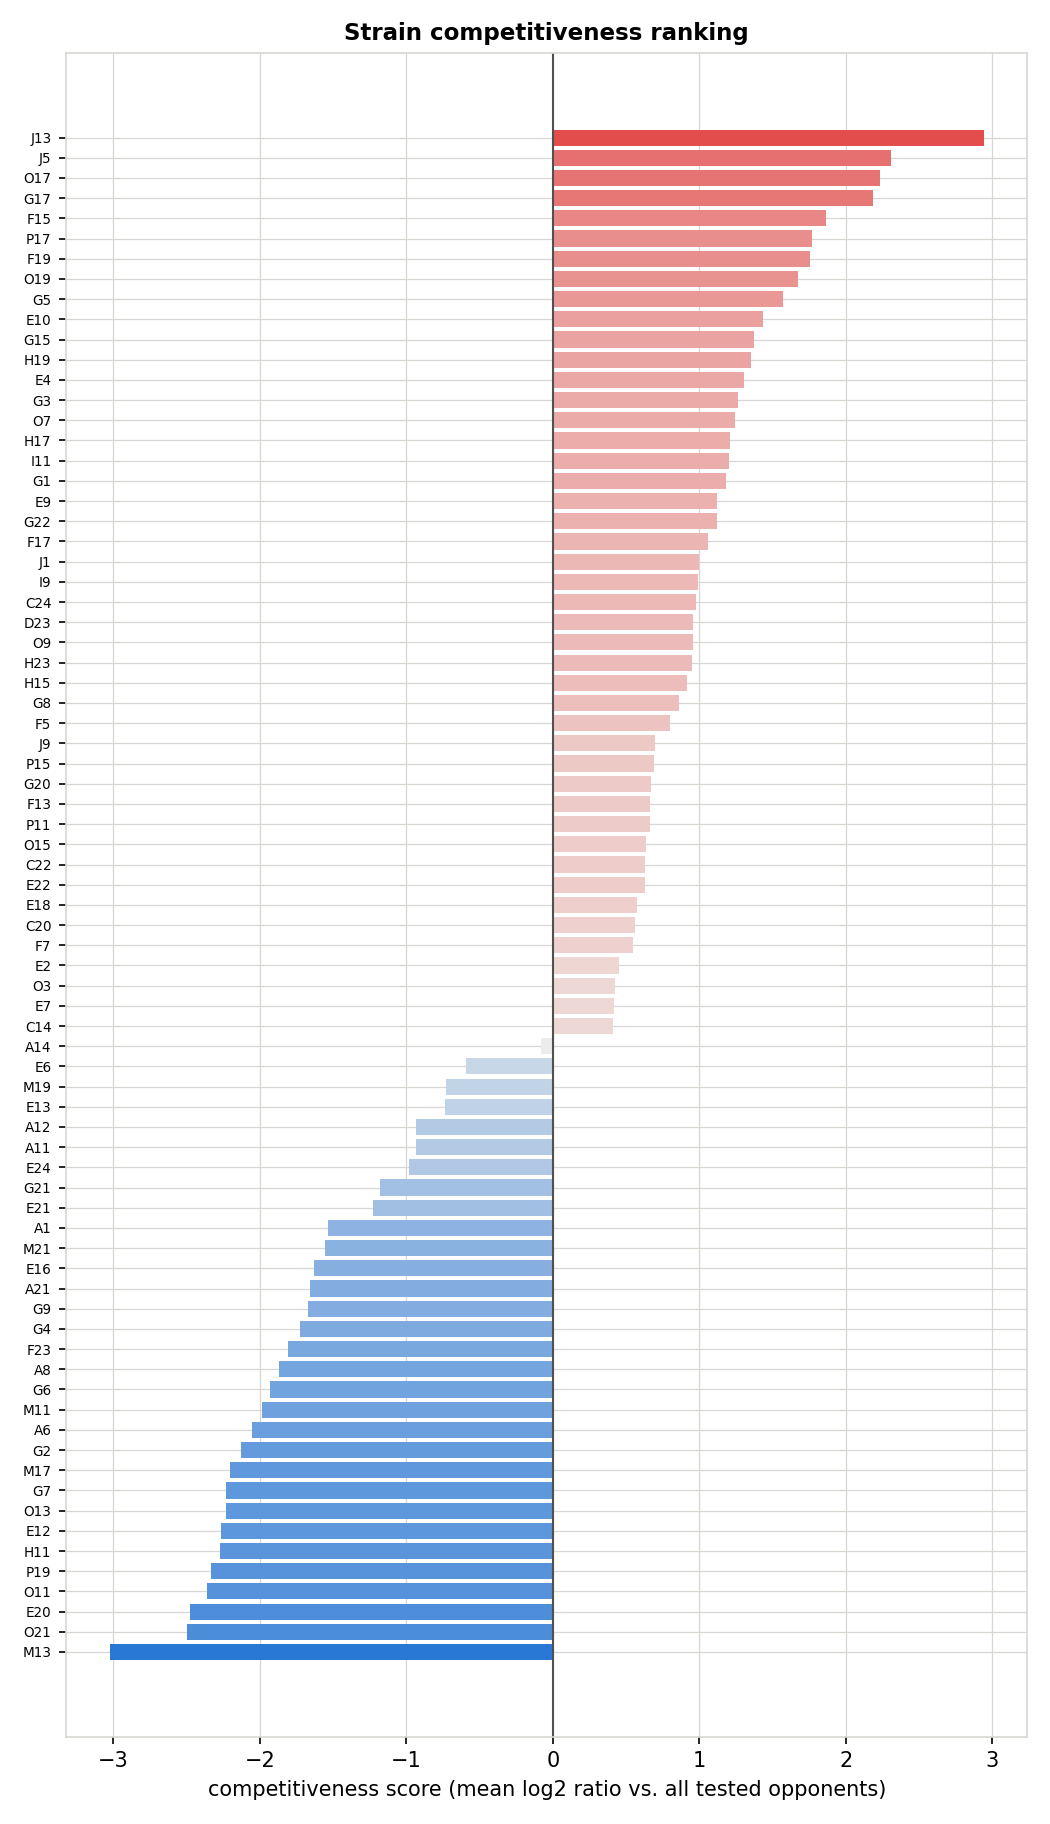

In [12]:
show("03_competitiveness_ranking.png", width=700)

## Step 5 — hierarchy vs. tangled network

In [13]:
from relative_abundance import hierarchy_analysis

bt, mat, win, hsummary = hierarchy_analysis(CFG)


76 strains with resolvable pairwise data
connected components: [76]

Bradley-Terry pseudo-R^2 (deviance explained by a single 1-D strength ranking): 0.831
median BT-residual sd across strains: 2.32 log2 units (the genuine, opponent-strength-corrected unpredictability of a strain's outcomes)
Directional Consistency Index (rank = total wins): 0.680  (976 consistent, 186 upsets)
Intransitive (cyclic) triads: 142/5746 evaluated (0.025)

saved -> r05_pairwise_relative_abundance_matrix.csv, r05_bt_strengths.csv, r05_hierarchy_summary.csv


In [14]:
display(hsummary)

,metric,value
0,n_strains_in_main_component,76.000000
1,n_components,1.000000
2,bt_pseudo_r2,0.831085
3,dci,0.679862
4,dci_n_consistent,976.000000
5,dci_n_inconsistent_upsets,186.000000
6,frac_intransitive_triads,0.024713
7,n_intransitive_triads,142.000000
8,n_triads_evaluated,5746.000000


**Pairwise outcome heatmap**, ordered by Bradley-Terry strength:

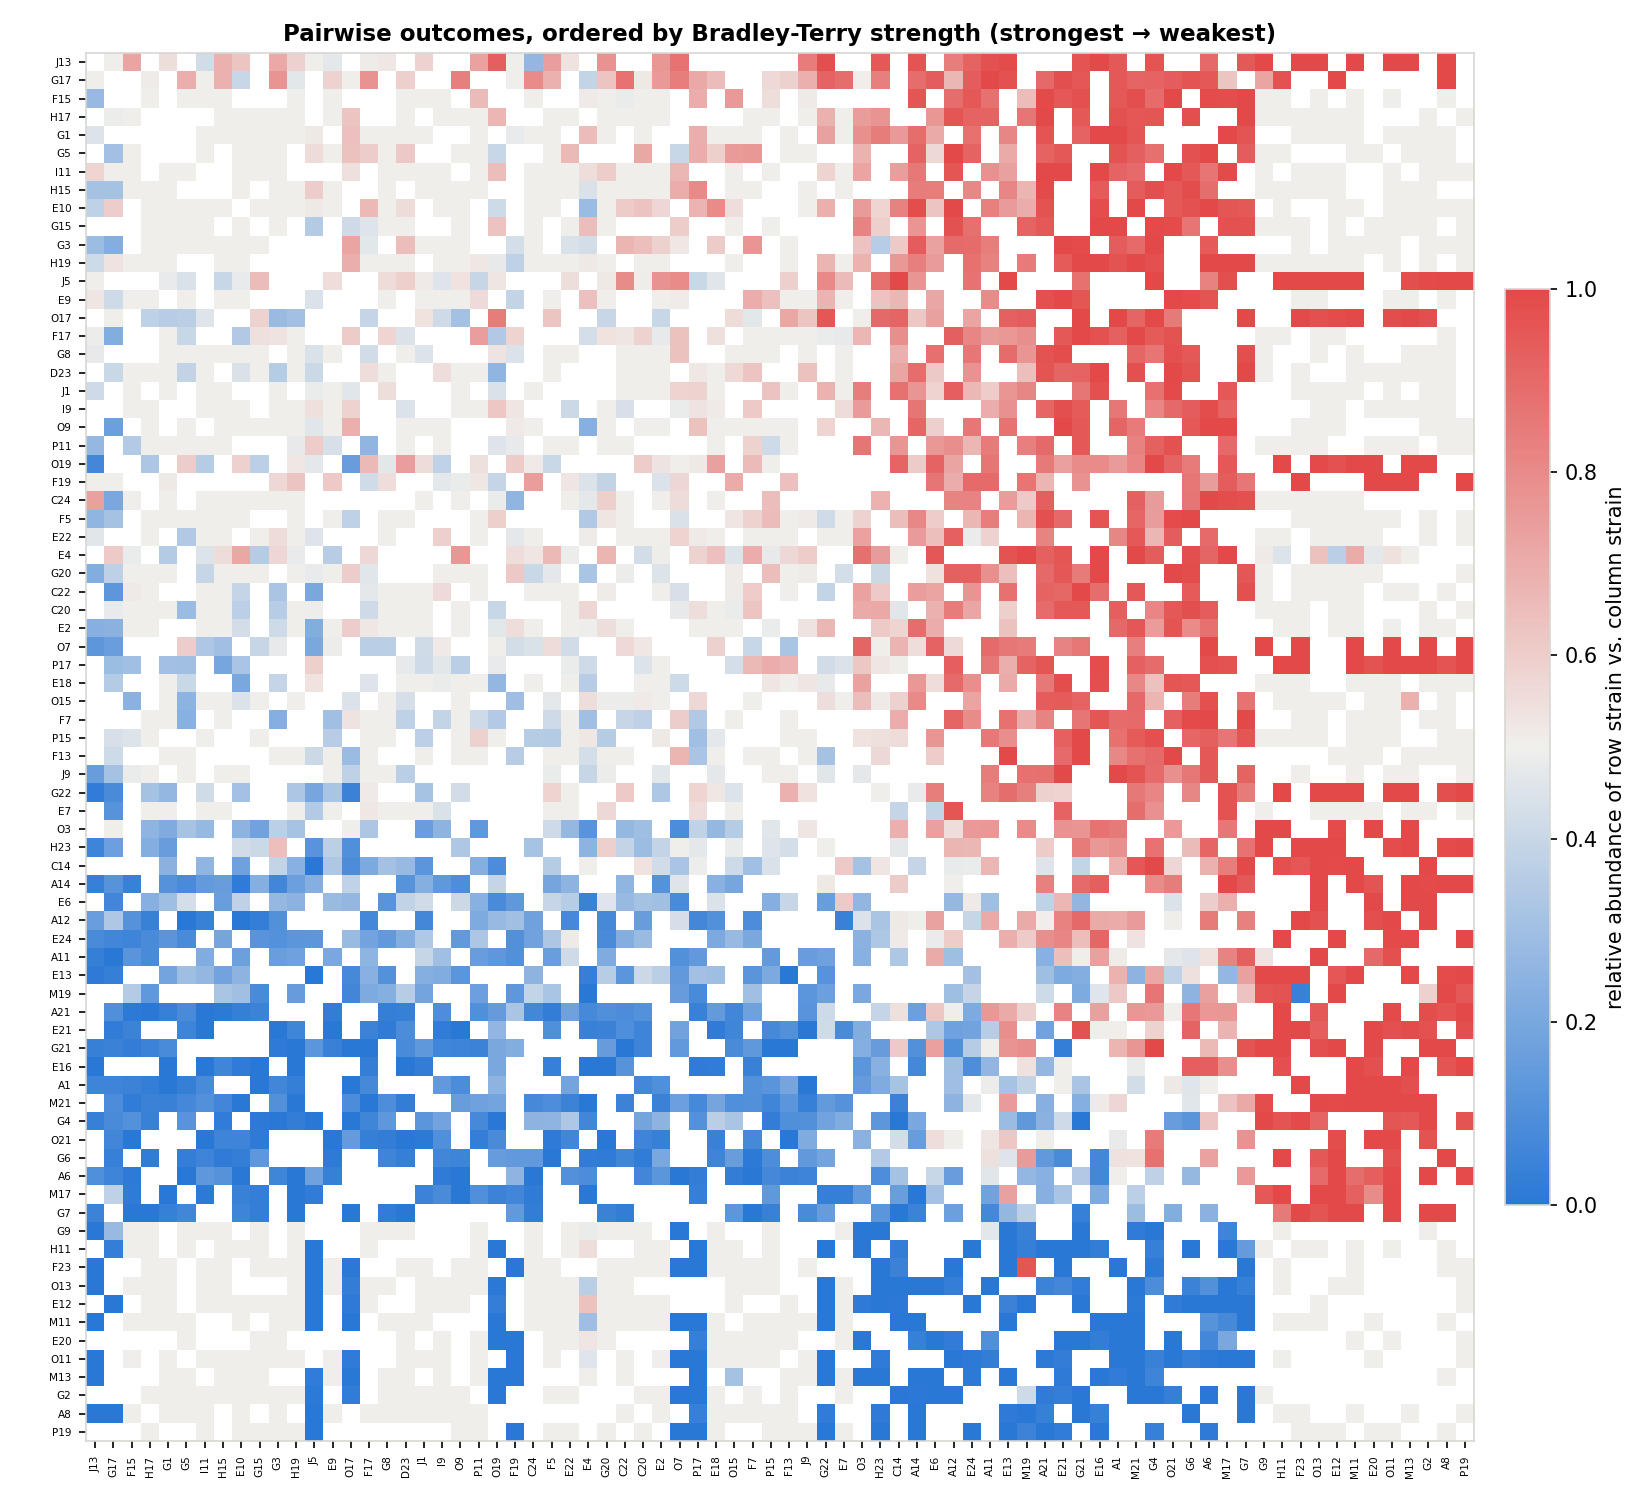

In [15]:
show("05_hierarchy_heatmap.png", width=780)

**Do the two independent competitiveness estimates agree?**

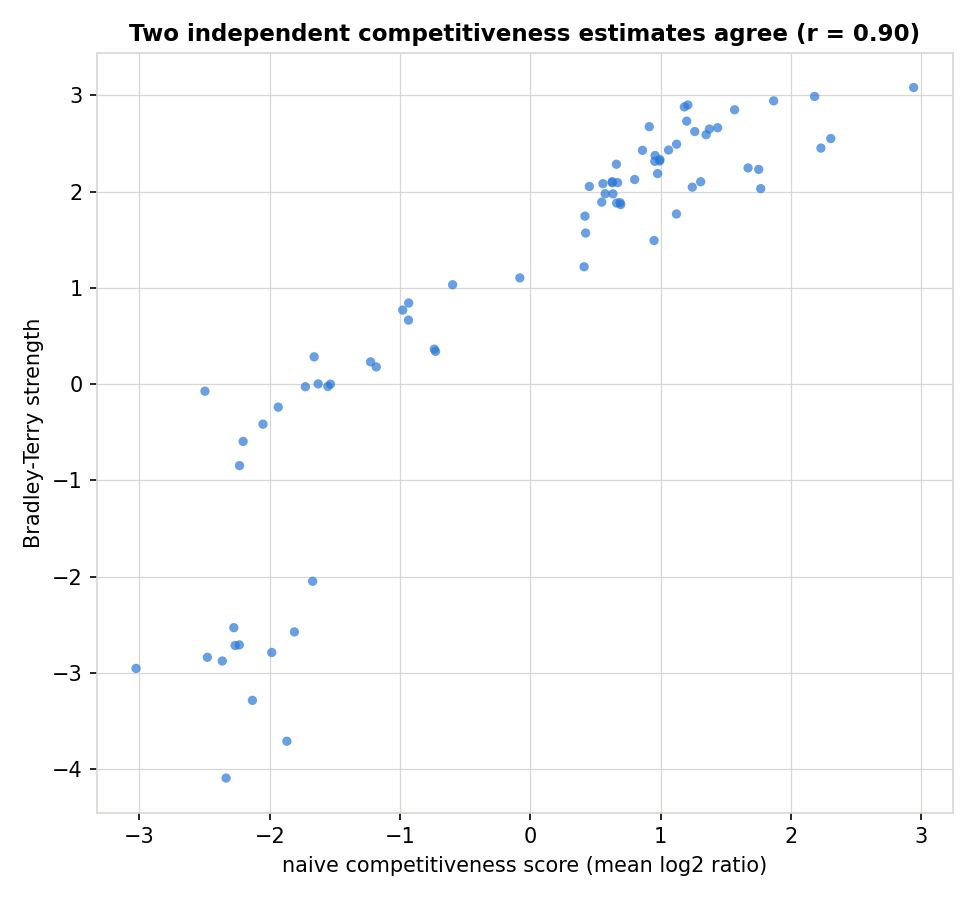

In [16]:
show("06_bt_vs_naive_competitiveness.png", width=520)

**Consistent dominance/loss vs. context-dependent outcomes**:

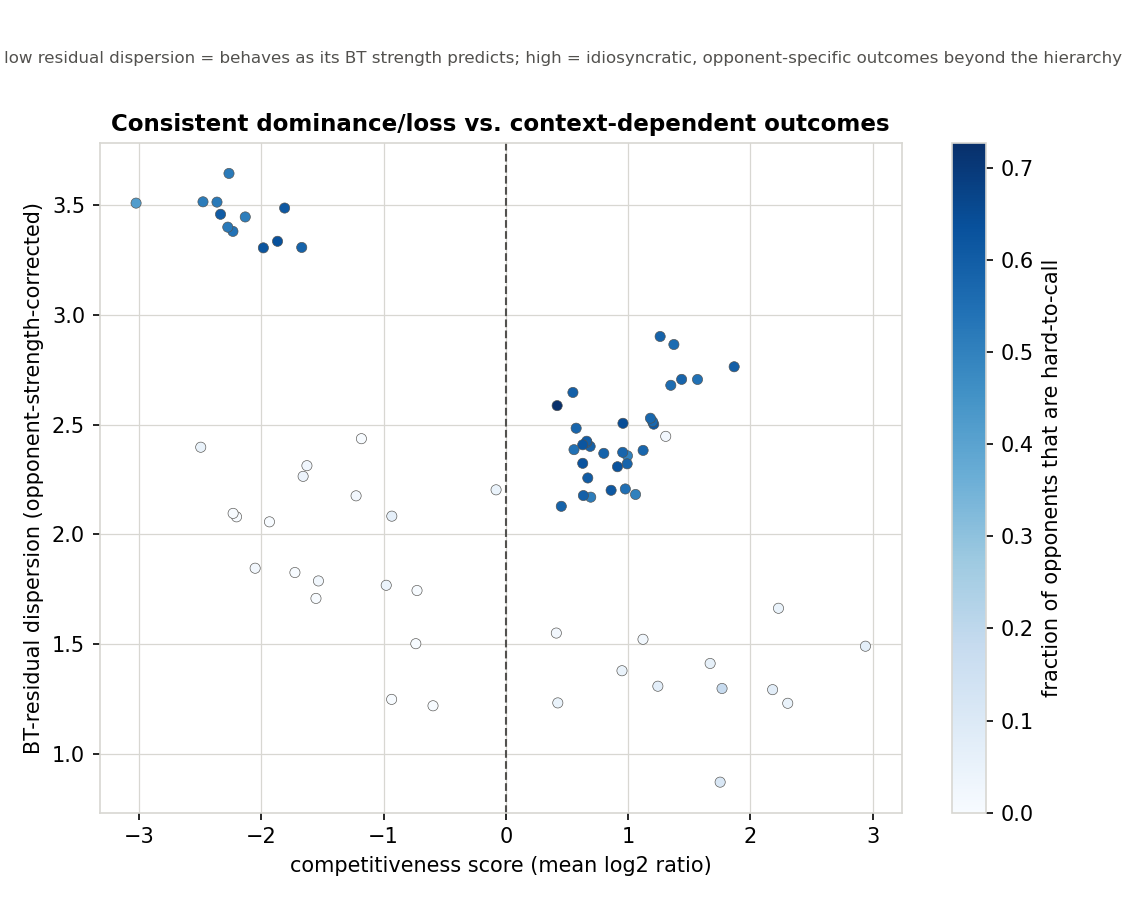

In [17]:
show("04_mean_vs_dispersion.png", width=680)

**Hierarchy consistency, summarized**:

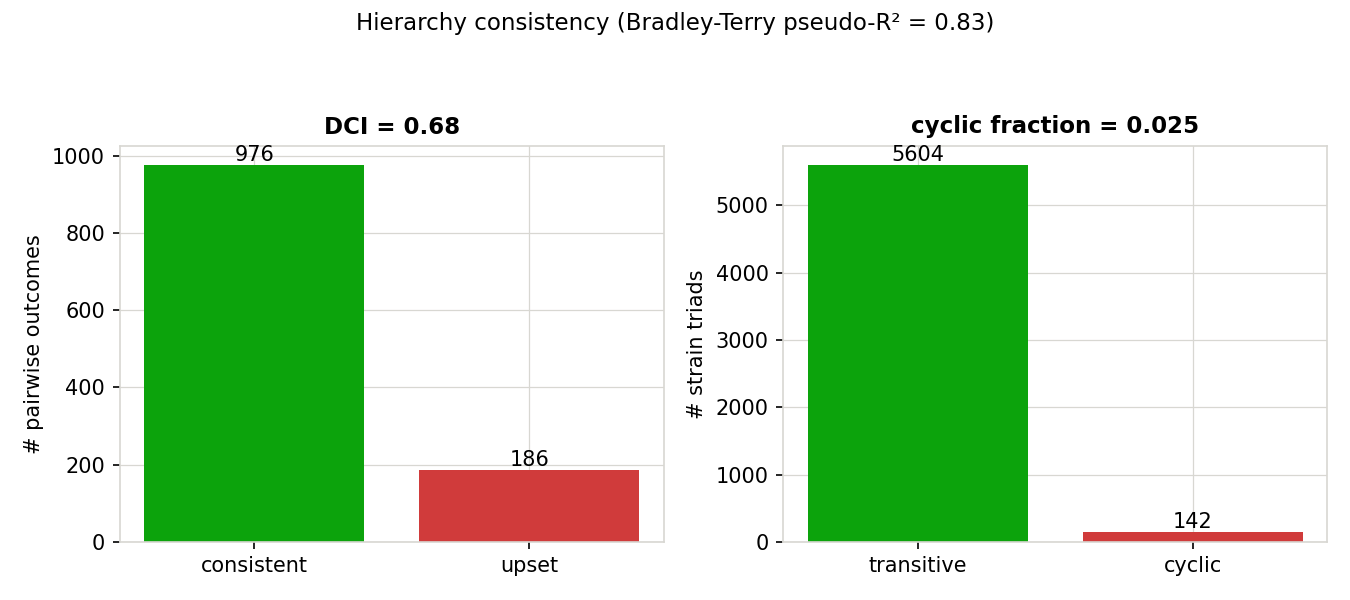

In [18]:
show("07_hierarchy_consistency.png", width=780)

## Key findings

**1. Interaction scores** — computed for 1,968/2,778 pair wells (810 skipped: one or both
strains lack a reference in `consensus2`, which covers 84/100 strains). Median off-target
read fraction is very low (0%), but a substantial share of wells are hard-to-call because
this strain set has a larger cluster of near-identical references than 20260721's.

**2. Replicate stability** — of 291 replicated pairs, most reproduce tightly (median std
≈ 0.03 once hard-to-call pairs are set aside); 11 show genuine replicate instability.

**3. Competitiveness scores** — 76/100 strains scored (`outputs/r04_strain_competitiveness.csv`).
`J13`, `J5`, `O17` lead; `M13`, `E20`, `O21` trail.

**4. Hierarchy, not a tangle — and strikingly similar to 20260721's independent result**:
Bradley-Terry pseudo-R²=0.83 (vs. 0.80 for 20260721), Directional Consistency Index=0.68
(vs. 0.69), and only 2.5% of evaluable strain triples are cyclic (vs. 3.1%). Two
independently-built, largely non-overlapping strain libraries both show the same
substantially-hierarchical-but-not-pure structure — a genuinely reassuring cross-experiment
consistency check on the method as much as a finding about either library specifically.

## Where everything lives

```
analysis/
├── config.py                              this experiment's ExperimentConfig
├── relative_abundance/
│   ├── scripts/                           thin wrappers over ../../../shared_pipelines/relative_abundance.py
│   ├── outputs/                           same file layout as 20260721's relative_abundance/outputs/
│   └── <this notebook>
└── mapping_validation/                    the read-mapping QC this cohort/reference is built on
```
